# **BUSINESS PROBLEM**

## The platform is facing challenges in converting active users into paying subscribers and retaining users over time. Additionally, there is limited visibility into behavioral patterns leading to churn.

# **PROJECT OBJECTIVE**

## Analyze user behavior and engagement patterns to uncover drivers of retention, conversion, and churn, and generate actionable insights to improve user retention and monetization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [2]:
users = pd.read_csv("users.csv")
events = pd.read_csv("events.csv")

In [3]:
events.columns.to_list()

['event_id',
 'user_id',
 'event_type',
 'event_time',
 'session_id',
 'platform',
 'subscription_id']

In [4]:
users.columns.to_list()

['user_id', 'signup_date', 'country', 'device', 'acquisition_channel']

In [5]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              10000 non-null  int64 
 1   signup_date          10000 non-null  object
 2   country              9483 non-null   object
 3   device               10000 non-null  object
 4   acquisition_channel  10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [6]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134289 entries, 0 to 134288
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   event_id         134289 non-null  int64  
 1   user_id          134289 non-null  int64  
 2   event_type       132946 non-null  object 
 3   event_time       134289 non-null  object 
 4   session_id       134289 non-null  int64  
 5   platform         134289 non-null  object 
 6   subscription_id  4227 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 7.2+ MB


## Business Problem: Users drop during onboarding and retention declines after Day 7, impacting subscription revenue.


- **Fixing Data Type**


In [7]:
users['signup_date'] = pd.to_datetime(users['signup_date'])

events['event_time'] = pd.to_datetime(events['event_time'])

events['subscription_id'] = events['subscription_id'].astype('Int64')

In [8]:
users.isnull().sum()

,0
user_id,0
signup_date,0
country,517
device,0
acquisition_channel,0


In [9]:
events.isnull().sum()

,0
event_id,0
user_id,0
event_type,1343
event_time,0
session_id,0
platform,0
subscription_id,130062


In [10]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134289 entries, 0 to 134288
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   event_id         134289 non-null  int64         
 1   user_id          134289 non-null  int64         
 2   event_type       132946 non-null  object        
 3   event_time       134289 non-null  datetime64[ns]
 4   session_id       134289 non-null  int64         
 5   platform         134289 non-null  object        
 6   subscription_id  4227 non-null    Int64         
dtypes: Int64(1), datetime64[ns](1), int64(3), object(2)
memory usage: 7.3+ MB


In [11]:
events['subscription_id'].unique()

<IntegerArray>
[  <NA>, 200234, 202819, 203345, 201284, 200177, 200142, 200342, 203177,
 200603,
 ...
 200033, 201453, 200725, 200441, 202847, 200840, 202711, 203267, 203202,
 200416]
Length: 3373, dtype: Int64

In [12]:
events.groupby('event_type')['subscription_id'].count()

,subscription_id
event_type,
add_to_watchlist,0
app_open,0
cancel_subscription,803
onboarding_complete,0
onboarding_start,0
play_content,0
search,0
subscribe,3374


In [13]:
events.head()

,event_id,user_id,event_type,event_time,session_id,platform,subscription_id
0,25215,1875,onboarding_start,2024-01-24 20:02:00,105821,ios,<NA>
1,85523,6379,search,2024-02-02 02:12:00,119838,ios,<NA>
2,62615,4699,app_open,2024-01-25 09:00:00,114514,ios,<NA>
3,61879,4639,play_content,2024-03-25 16:22:00,114348,ios,<NA>
4,5939,464,add_to_watchlist,2024-02-12 23:07:00,101373,ios,<NA>


In [14]:
events.groupby('event_type')['subscription_id'].agg(['count', 'size'])

,count,size
event_type,,
add_to_watchlist,0,27568
app_open,0,30893
cancel_subscription,803,803
onboarding_complete,0,5834
onboarding_start,0,9020
play_content,0,27777
search,0,27677
subscribe,3374,3374


In [15]:
events.groupby('subscription_id')['event_type'].unique()

,event_type
subscription_id,
200000,[subscribe]
200001,"[subscribe, cancel_subscription]"
200002,[subscribe]
200003,[subscribe]
200004,"[subscribe, cancel_subscription]"
...,...
203367,[subscribe]
203368,[subscribe]
203369,[subscribe]


In [16]:
# correcting subscription_id column order
events= events.sort_values(by=['subscription_id', 'event_time'])

In [17]:
events.groupby('subscription_id')['event_type'].apply(list)

,event_type
subscription_id,
200000,[subscribe]
200001,"[subscribe, cancel_subscription]"
200002,[subscribe]
200003,[subscribe]
200004,"[subscribe, cancel_subscription]"
...,...
203367,[subscribe]
203368,[subscribe]
203369,[subscribe]


- **Fixing Null values in tables**

In [18]:
users['country'] = users['country'].fillna('Unknown')

In [19]:
t = events[events['event_type'].isnull()][['event_type', 'subscription_id']]
t

,event_type,subscription_id
4149,NaN,200034
15430,NaN,200080
20952,NaN,200090
78367,NaN,200116
84231,NaN,200120
...,...,...
130826,NaN,<NA>
127184,NaN,<NA>
35721,NaN,<NA>
39609,NaN,<NA>


In [20]:
events['event_type'].unique()

array(['subscribe', 'cancel_subscription', nan, 'app_open',
       'onboarding_start', 'search', 'onboarding_complete',
       'play_content', 'add_to_watchlist'], dtype=object)

In [21]:
events['event_type'] = events['event_type'].fillna('UnknownEvent')

In [22]:
events.isna().sum()

,0
event_id,0
user_id,0
event_type,0
event_time,0
session_id,0
platform,0
subscription_id,130062


In [23]:
users.isna().sum()

,0
user_id,0
signup_date,0
country,0
device,0
acquisition_channel,0


In [24]:
events['event_type'].unique()

array(['subscribe', 'cancel_subscription', 'UnknownEvent', 'app_open',
       'onboarding_start', 'search', 'onboarding_complete',
       'play_content', 'add_to_watchlist'], dtype=object)

## **Creating Helper Tables**
- **subscriptions table**

In [25]:
subs = events[events['event_type'].isin(['subscribe', 'cancel_subscription'])]

subs = subs.sort_values(['subscription_id', 'event_time'])

subs = subs.drop_duplicates()

subscriptions = subs.groupby('subscription_id').agg(
    user_id=('user_id', 'first'),
    subscription_start=('event_time', 'first'),
    subscription_end=('event_time', 'last'),
    last_event=('event_type', 'last')
).reset_index()

subscriptions['status'] = subscriptions['last_event'].map({
    'subscribe': 'active',
    'cancel_subscription': 'churned'
})

# Fix end date for active users
subscriptions.loc[subscriptions['status'] == 'active', 'subscription_end'] = pd.NaT

In [26]:
subscriptions

,subscription_id,user_id,subscription_start,subscription_end,last_event,status
0,200000,3,2024-03-17 16:30:00,NaT,subscribe,active
1,200001,4,2024-01-06 13:30:00,2024-01-20 10:00:00,cancel_subscription,churned
2,200002,4,2024-01-10 00:30:00,NaT,subscribe,active
3,200003,5,2024-02-01 04:30:00,NaT,subscribe,active
4,200004,7,2024-04-06 04:30:00,2024-05-17 19:00:00,cancel_subscription,churned
...,...,...,...,...,...,...
3340,203367,9980,2024-03-12 16:30:00,NaT,subscribe,active
3341,203368,9983,2024-01-23 09:30:00,NaT,subscribe,active
3342,203369,9985,2024-02-22 12:30:00,NaT,subscribe,active
3343,203370,9989,2024-04-02 22:30:00,NaT,subscribe,active


In [27]:
subscriptions['event_count'] = subs.groupby('subscription_id')['event_type'].count().values

In [28]:
subscriptions['event_count'].value_counts()

,count
event_count,
1,2560
2,785


In [29]:
subscriptions.sort_values('event_count', ascending = False)

,subscription_id,user_id,subscription_start,subscription_end,last_event,status,event_count
15,200015,24,2024-02-29 02:30:00,2024-03-27 19:00:00,cancel_subscription,churned,2
14,200014,22,2024-03-19 03:30:00,2024-04-12 08:00:00,cancel_subscription,churned,2
12,200012,20,2024-02-28 22:30:00,2024-03-15 10:00:00,cancel_subscription,churned,2
10,200010,19,2024-03-05 02:30:00,2024-03-13 19:00:00,cancel_subscription,churned,2
6,200006,9,2024-03-02 17:30:00,2024-03-20 01:00:00,cancel_subscription,churned,2
...,...,...,...,...,...,...,...
3333,203360,9956,2024-03-07 07:30:00,NaT,subscribe,active,1
3332,203359,9949,2024-01-02 13:30:00,NaT,subscribe,active,1
3331,203358,9948,2024-01-12 06:30:00,NaT,subscribe,active,1
3330,203357,9946,2024-03-06 04:30:00,NaT,subscribe,active,1


In [30]:
subs[subs['subscription_id'] == 201552]

,event_id,user_id,event_type,event_time,session_id,platform,subscription_id
19339,59933,4484,subscribe,2024-02-08 02:30:00,113889,ios,201552
127268,59936,4484,cancel_subscription,2024-02-25 10:00:00,113890,ios,201552


In [31]:
subscriptions['duration_days'] = (
    subscriptions['subscription_end'] - subscriptions['subscription_start']
).dt.days

In [32]:
subscriptions.head()

,subscription_id,user_id,subscription_start,subscription_end,last_event,status,event_count,duration_days
0,200000,3,2024-03-17 16:30:00,NaT,subscribe,active,1,NaN
1,200001,4,2024-01-06 13:30:00,2024-01-20 10:00:00,cancel_subscription,churned,2,13.0
2,200002,4,2024-01-10 00:30:00,NaT,subscribe,active,1,NaN
3,200003,5,2024-02-01 04:30:00,NaT,subscribe,active,1,NaN
4,200004,7,2024-04-06 04:30:00,2024-05-17 19:00:00,cancel_subscription,churned,2,41.0


## **Creating Sessions Table**

In [33]:
events.head()

,event_id,user_id,event_type,event_time,session_id,platform,subscription_id
118013,23,3,subscribe,2024-03-17 16:30:00,100003,android,200000
111650,43,4,subscribe,2024-01-06 13:30:00,100006,android,200001
119317,49,4,cancel_subscription,2024-01-20 10:00:00,100008,android,200001
119979,57,4,subscribe,2024-01-10 00:30:00,100010,android,200002
20892,78,5,subscribe,2024-02-01 04:30:00,100014,ios,200003


In [34]:
events.groupby('session_id')['platform'].nunique().value_counts()

,count
platform,
1,30876


In [35]:
events['event_type'].unique()

array(['subscribe', 'cancel_subscription', 'UnknownEvent', 'app_open',
       'onboarding_start', 'search', 'onboarding_complete',
       'play_content', 'add_to_watchlist'], dtype=object)

In [36]:
# Aggregate events to session grain
sessions = events.groupby(['session_id', 'user_id']).agg(
    session_start=('event_time', 'min'),
    session_end=('event_time', 'max'),
    platform=('platform', 'first'),
    total_events=('event_id', 'count')
).reset_index()

# Calculate duration in minutes
sessions['duration_minutes'] = (
    (sessions['session_end'] - sessions['session_start']).dt.total_seconds() / 60
)

In [37]:
# Creating is_viewing_session column
viewing_sessions = events[events['event_type'] == 'play_content']['session_id'].unique()

sessions['is_viewing_session'] = sessions['session_id'].isin(viewing_sessions)

# creating session_date column
sessions['session_date'] = sessions['session_start'].dt.date

In [38]:
sessions

,session_id,user_id,session_start,session_end,platform,total_events,duration_minutes,is_viewing_session,session_date
0,100000,1,2024-02-21 12:00:00,2024-02-21 12:12:00,ios,5,12.0,False,2024-02-21
1,100001,2,2024-01-23 08:00:00,2024-01-23 08:17:00,web,6,17.0,True,2024-01-23
2,100002,2,2024-01-25 06:00:00,2024-01-25 06:17:00,web,4,17.0,True,2024-01-25
3,100003,3,2024-03-17 16:00:00,2024-03-17 16:30:00,android,8,30.0,True,2024-03-17
4,100004,4,2024-01-03 00:00:00,2024-01-03 00:22:00,android,7,22.0,True,2024-01-03
...,...,...,...,...,...,...,...,...,...
30871,130871,10000,2024-03-14 12:00:00,2024-03-14 12:22:00,web,8,22.0,True,2024-03-14
30872,130872,10000,2024-03-16 18:00:00,2024-03-16 18:12:00,web,3,12.0,True,2024-03-16
30873,130873,10000,2024-03-27 11:00:00,2024-03-27 11:17:00,web,4,17.0,True,2024-03-27
30874,130874,10000,2024-03-28 11:00:00,2024-03-28 11:17:00,web,4,17.0,True,2024-03-28


## **Creating user_activity table**

In [39]:
#  Aggregate to user-day level
user_activity = sessions.groupby(['user_id', 'session_date']).agg(
    total_sessions=('session_id', 'count'),
    total_minutes=('duration_minutes', 'sum'),
    viewing_sessions=('is_viewing_session', 'sum')
).reset_index()

#  Behavioral flags
user_activity['is_active'] = user_activity['total_sessions'] > 0
user_activity['is_engaged'] = user_activity['viewing_sessions'] > 0

In [40]:
user_activity

,user_id,session_date,total_sessions,total_minutes,viewing_sessions,is_active,is_engaged
0,1,2024-02-21,1,12.0,0,True,False
1,2,2024-01-23,1,17.0,1,True,True
2,2,2024-01-25,1,17.0,1,True,True
3,3,2024-03-17,1,30.0,1,True,True
4,4,2024-01-03,1,22.0,1,True,True
...,...,...,...,...,...,...,...
26546,10000,2024-03-14,1,22.0,1,True,True
26547,10000,2024-03-16,1,12.0,1,True,True
26548,10000,2024-03-27,1,17.0,1,True,True
26549,10000,2024-03-28,1,17.0,1,True,True


# Business Questions
### **```Q1. Do users with viewing sessions convert more than users without?```**

In [41]:
# First viewing date per user

first_view = sessions[sessions['is_viewing_session'] == True] \
    .groupby('user_id')['session_start'].min().reset_index()

first_view.columns = ['user_id', 'first_view_date']

# First subscription date

first_sub = subscriptions.groupby('user_id')['subscription_start'] \
    .min().reset_index()

first_sub.columns = ['user_id', 'first_sub_date']

# user summary (merge)

user_summary = users[['user_id']].copy()

user_summary = user_summary.merge(first_view, on='user_id', how='left')
user_summary = user_summary.merge(first_sub, on='user_id', how='left')

# defining proper flags
user_summary['viewed_before_sub'] = (
    (user_summary['first_view_date'].notna()) &
    (user_summary['first_sub_date'].notna()) &
    (user_summary['first_view_date'] < user_summary['first_sub_date'])
)

user_summary['has_subscribed'] = user_summary['first_sub_date'].notna()

In [42]:
# user first view
user_summary['has_viewed'] = user_summary['first_view_date'].notna()

# converted users
user_summary['has_subscribed'] = user_summary['first_sub_date'].notna()
#conversion comparision
conversion = user_summary.groupby('has_viewed')['has_subscribed'].mean() * 100
print(conversion)


has_viewed
False     6.779661
True     38.785770
Name: has_subscribed, dtype: float64


/tmp/ipykernel_64507/1569539282.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=groups, y=rates, palette=['#e74c3c', '#2ecc71'])


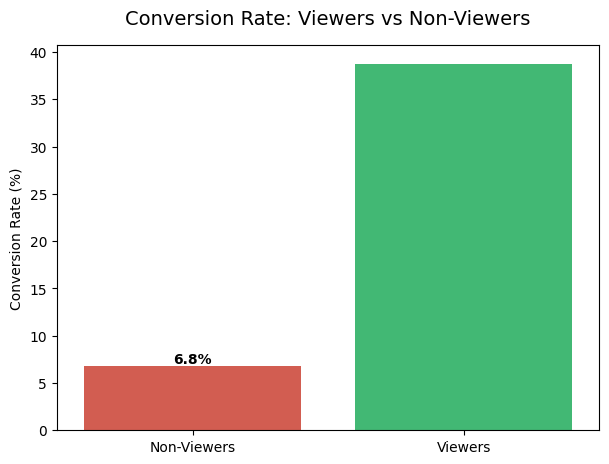

In [43]:
groups = ['Non-Viewers', 'Viewers']
rates = [6.78, 38.79] # Values from your result

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=groups, y=rates, palette=['#e74c3c', '#2ecc71'])

plt.title('Conversion Rate: Viewers vs Non-Viewers', fontsize=14, pad=15)
plt.ylabel('Conversion Rate (%)')
ax.bar_label(ax.containers[0], fmt='%.1f%%', fontweight='bold')

plt.show()

- Interpretation : Users who watch content are nearly 6x more likely ($38.8\%$ vs $6.8\%$) to subscribe than those who don't.

### **```Q2. Do users with viewing sessions have higher retention than non-viewing users?```**

In [44]:
# Prepare & data correction
user_activity['session_date'] = pd.to_datetime(user_activity['session_date'])
users['signup_date'] = pd.to_datetime(users['signup_date'])

retention_df = user_activity.merge(users[['user_id', 'signup_date']],on='user_id',how='left')

retention_df['days_since_signup'] = (retention_df['session_date'] -
                                     retention_df['signup_date']).dt.days

# Eligible users (Day 7)
max_date = retention_df['session_date'].max()

eligible_users = users[(max_date - users['signup_date']).dt.days >= 7]['user_id']

# Day 7 active users
day7_active = retention_df[retention_df['days_since_signup'] == 7]['user_id']

# Viewing flag at user level
users['has_viewed'] = users['user_id'].isin(sessions[sessions['is_viewing_session']]['user_id'])

# Merge flags
retention_users = users[users['user_id'].isin(eligible_users)].copy()
retention_users['retained_day7'] = retention_users['user_id'].isin(day7_active)

# Final comparison
result = retention_users.groupby('has_viewed')['retained_day7'].mean() * 100

print(result)

has_viewed
False     1.873327
True     13.650425
Name: retained_day7, dtype: float64


- **Interpretation:** _Users who consume content are ~7x more likely to return on Day 7, indicating that content engagement is a key driver of retention._

### **```Q3. What % of sessions are viewing vs non-viewing?```**

In [45]:
session_split = sessions['is_viewing_session'].value_counts(normalize=True) * 100

print(session_split)

is_viewing_session
True     58.362482
False    41.637518
Name: proportion, dtype: float64


- Around 58% viewing sessions = healthy engagement baseline

### **```Q3. Do users with higher session frequency retain more?```**

In [46]:
# Merge & prepare
df = user_activity.merge(users[['user_id', 'signup_date']], on='user_id')
df['days_since_signup'] = (pd.to_datetime(df['session_date']) - pd.to_datetime(df['signup_date'])).dt.days

# Sessions in first 7 days
early = df[df['days_since_signup'] <= 7]

# Total sessions per user
freq = early.groupby('user_id')['total_sessions'].sum()

# High vs Low
freq_group = freq.apply(lambda x: 'High' if x > 2 else 'Low')

# Day 7 retention
day7_users = df[df['days_since_signup'] == 7]['user_id']

result = (freq_group.to_frame('group')
    .assign(retained=lambda x: x.index.isin(day7_users))
    .groupby('group')['retained']
    .mean() * 100)

print(result)

group
High    24.484991
Low      4.406946
Name: retained, dtype: float64


/tmp/ipykernel_64507/1158755263.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=result.index, y=result.values, palette=['green', 'red'])


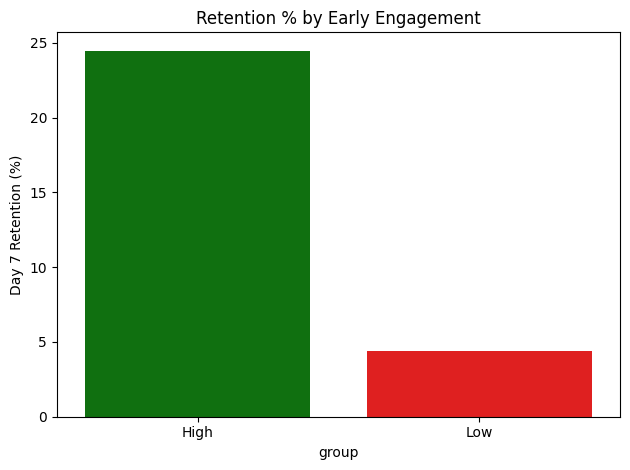

In [47]:
sns.barplot(x=result.index, y=result.values, palette=['green', 'red'])

plt.title('Retention % by Early Engagement')
plt.ylabel('Day 7 Retention (%)')
plt.tight_layout()
plt.show()

- **Finding** : Users who are highly active in their first week are ~5.5x more likely to return on Day 7, indicating early usage intensity is a strong predictor of retention

### **```Q4. MONETIZATION: What is the overall conversion rate?```**

In [48]:
total_users = users['user_id'].nunique()
converted_users = subscriptions['user_id'].nunique()

conversion_rate = (converted_users / total_users) * 100

print(f"Overall Conversion Rate: {conversion_rate:.2f}%")

Overall Conversion Rate: 31.61%


### **```Q5. MONETIZATION: How many users are active but not subscribed?```**

In [49]:
# Active users (from user_activity)
active_users = user_activity['user_id'].unique()

# Subscribed users
subscribed_users = subscriptions['user_id'].unique()

# Active but NOT subscribed
active_not_subscribed = set(active_users) - set(subscribed_users)

# Count
count_active_not_sub = len(active_not_subscribed)

# Percentage (out of active users)
percentage = (count_active_not_sub / len(active_users)) * 100

print(f"Active but Not Subscribed: {count_active_not_sub} users ({percentage:.2f}%)")

Active but Not Subscribed: 6839 users (68.39%)


- **Findings:** A significant 68% of active users are not subscribed, indicating a large monetization gap despite ongoing engagement.

### **```Q6. Do subscribed users behave differently than non-subscribed users?```**

In [50]:
# Subscribed users
sub_users = subscriptions['user_id']

# User-level engagement
eng = user_activity.groupby('user_id').agg(
    viewing=('viewing_sessions', 'sum'),
    days=('session_date', 'count')
)

eng['avg_viewing'] = eng['viewing'] / eng['days']
eng['is_subscribed'] = eng.index.isin(sub_users)

# Compare
result = eng.groupby('is_subscribed')['avg_viewing'].mean()

# Clean output
non_sub = result[False]
sub = result[True]
print(result)
print(f"Subscribed users watch {((sub/non_sub - 1)*100):.0f}% more content per active day than non-subscribed users.")

is_subscribed
False    0.564375
True     0.792650
Name: avg_viewing, dtype: float64
Subscribed users watch 40% more content per active day than non-subscribed users.


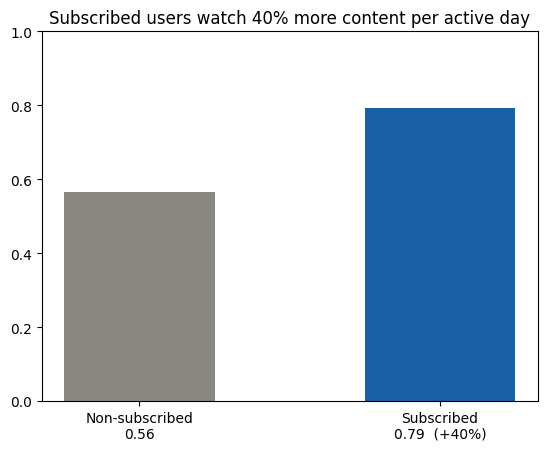

In [51]:
plt.bar(['Non-subscribed\n0.56', 'Subscribed\n0.79  (+40%)'], [non_sub, sub],
        color=['#888780', '#185FA5'], width=0.5)
plt.ylim(0, 1.0)
plt.title('Subscribed users watch 40% more content per active day')
plt.show()

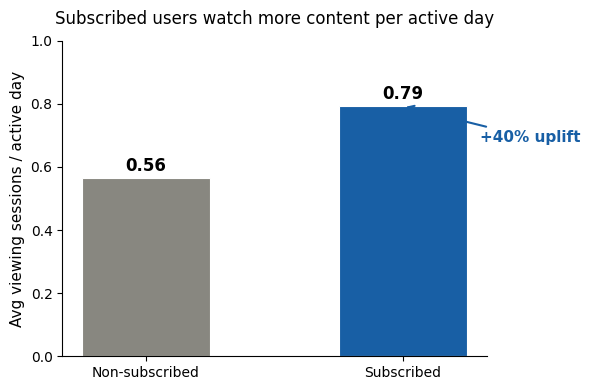

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = ['Non-subscribed', 'Subscribed']
values = [non_sub, sub]
colors = ['#888780', '#185FA5']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.annotate(f'+{((sub/non_sub - 1)*100):.0f}% uplift',
            xy=(1, sub), xytext=(1.3, (sub + non_sub)/2),
            fontsize=11, color='#185FA5', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#185FA5', lw=1.5))

ax.set_ylabel('Avg viewing sessions / active day', fontsize=11)
ax.set_ylim(0, 1.0)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title('Subscribed users watch more content per active day', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

### **```Q7. Do churned users show declining engagement before churn?```**

In [53]:

# Filter engagement events


engagement_events = [
    'app_open',
    'search',
    'play_content',
    'add_to_watchlist',
    'onboarding_start',
    'onboarding_complete']

eng_events = events[events['event_type'].isin(engagement_events)].copy()

# Ensure datetime
eng_events['event_time'] = pd.to_datetime(eng_events['event_time'])
subscriptions['subscription_end'] = pd.to_datetime(subscriptions['subscription_end'])

# Getting churned users


churned = subscriptions[subscriptions['status'] == 'churned'][['user_id', 'subscription_end']]

# Merge events with churn date

df = eng_events.merge(churned, on='user_id')

# Calculate days before churn


df['days_before_churn'] = ( df['subscription_end'] - df['event_time']).dt.days


# Split periods

# Last 7 days before churn
last_7 = df[(df['days_before_churn'] >= 0) & (df['days_before_churn'] <= 7)]

# Earlier period
earlier = df[df['days_before_churn'] > 7]


# Engagement metric


# Using number of events as engagement
last7_avg = last_7.groupby('user_id')['event_id'].count().mean()
earlier_avg = earlier.groupby('user_id')['event_id'].count().mean()

print(f"Last 7 Days Avg Engagement Events: {last7_avg:.2f}")
print(f"Earlier Avg Engagement Events: {earlier_avg:.2f}")

# % change
change = ((last7_avg - earlier_avg) / earlier_avg) * 100

print(f"Change before churn: {change:.2f}%")

Last 7 Days Avg Engagement Events: 10.38
Earlier Avg Engagement Events: 26.03
Change before churn: -60.14%


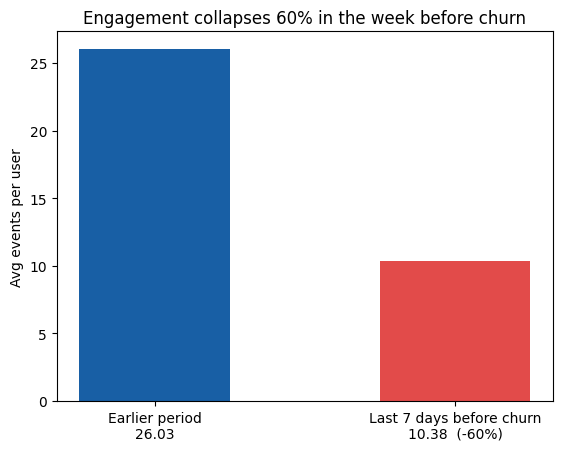

In [54]:
plt.bar(['Earlier period\n26.03', 'Last 7 days before churn\n10.38  (-60%)'],
        [earlier_avg, last7_avg], color=['#185FA5', '#E24B4A'], width=0.5)
plt.ylabel('Avg events per user')
plt.title('Engagement collapses 60% in the week before churn')
plt.show()

- **FIndings:** Users exhibit a sharp decline (~60%) in overall engagement in the week leading up to churn, indicating disengagement as a strong leading indicator of churn.”

---

### **```Q8. Are there users who churn but remain active?```**

In [55]:

# Defining engagement events
# =========================

engagement_events = [
    'app_open',
    'search',
    'play_content',
    'add_to_watchlist',
    'onboarding_start',
    'onboarding_complete']

eng_events = events[events['event_type'].isin(engagement_events)].copy()

# Ensure datetime
eng_events['event_time'] = pd.to_datetime(eng_events['event_time'])
subscriptions['subscription_end'] = pd.to_datetime(subscriptions['subscription_end'])


# Get churned users

churned = subscriptions[subscriptions['status'] == 'churned'][['user_id', 'subscription_end']]


# Merging events with churn date

df = eng_events.merge(churned, on='user_id', how='inner')

# activity AFTER churn

df['active_after_churn'] = df['event_time'] > df['subscription_end']

# Users active after churn
active_after_users = df[df['active_after_churn']]['user_id'].unique()

# Final metrics

total_churned = churned['user_id'].nunique()
active_after_count = len(active_after_users)

percentage = (active_after_count / total_churned) * 100 if total_churned > 0 else 0

# Output

print(f"Total Churned Users: {total_churned}")
print(f"Active After Churn Users: {active_after_count}")
print(f"Percentage Active After Churn: {percentage:.2f}%")

Total Churned Users: 751
Active After Churn Users: 41
Percentage Active After Churn: 5.46%


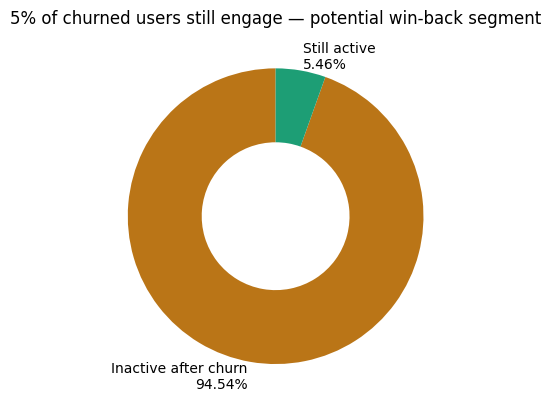

In [56]:
plt.pie([710, 41], labels=['Inactive after churn\n94.54%', 'Still active\n5.46%'],
        colors=['#BA7517', '#1D9E75'], startangle=90,
        wedgeprops=dict(width=0.5))
plt.title('5% of churned users still engage — potential win-back segment')
plt.show()

- **Interpretation:** Only ~5% of churned users continue to engage after cancelling their subscription
- The vast majority of users (~95%) stop engaging with the platform after churn, indicating that churn is strongly associated with complete disengagement rather than partial usage._
- _Users show a sharp decline in engagement before churn and largely disengage completely after churn, indicating that churn is a terminal event rather than a reversible state._

---

### **```Q9. Which platform (android / ios / web) performs better in engagement and conversion?```**

In [57]:
# =========================
# STEP 1: Engagement by platform
# =========================

# Filter engagement events
engagement_events = [
    'app_open',
    'search',
    'play_content',
    'add_to_watchlist',
    'onboarding_start',
    'onboarding_complete']

eng = events[events['event_type'].isin(engagement_events)].copy()

# Count engagement per user per platform
engagement = eng.groupby(['platform', 'user_id']).size().reset_index(name='engagement_events')

# Average engagement per user
engagement_avg = engagement.groupby('platform')['engagement_events'].mean()


# Conversion by platform

# Get users with platform (based on first occurrence)
user_platform = events.sort_values('event_time').groupby('user_id')['platform'].first().reset_index()

# Add subscription flag
user_platform['is_subscribed'] = user_platform['user_id'].isin(subscriptions['user_id'])

# Conversion rate per platform
conversion = user_platform.groupby('platform')['is_subscribed'].mean() * 100


# Combining results
# =========================

final = pd.concat([engagement_avg, conversion], axis=1)
final.columns = ['avg_engagement', 'conversion_rate']

print(final)

          avg_engagement  conversion_rate
platform                                 
android        12.931835        31.507195
ios            12.860292        32.226901
web            12.801698        30.569431


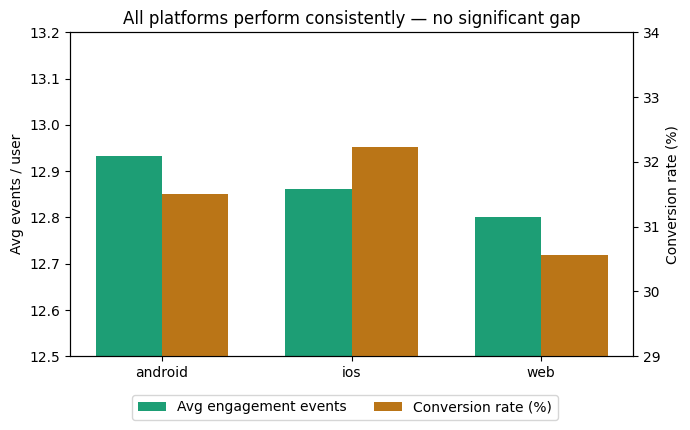

In [58]:

platforms = final.index.tolist()
x = np.arange(len(platforms))
width = 0.35

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.bar(x - width/2, final['avg_engagement'], width, color='#1D9E75', label='Avg engagement events')
ax2.bar(x + width/2, final['conversion_rate'], width, color='#BA7517', label='Conversion rate (%)')

ax1.set_xticks(x)
ax1.set_xticklabels(platforms)
ax1.set_ylabel('Avg events / user')
ax2.set_ylabel('Conversion rate (%)')

ax1.set_ylim(12.5, 13.2)
ax2.set_ylim(29, 34)

fig.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.08))
plt.title('All platforms perform consistently — no significant gap')
plt.tight_layout()
plt.show()

- **Interpretation:** Engagement and conversion rates are broadly consistent across Android, iOS, and Web platforms, with no significant performance gap observed

---

# Project Summary for Stakeholders

## 1. Business Problem

The platform is facing significant challenges in converting active users into paying subscribers and retaining them over time. There is a lack of clear understanding regarding user behavioral patterns that lead to churn, which directly impacts subscription revenue and overall growth.

## 2. Project Objective

The primary objective of this project was to analyze user behavior and engagement patterns to identify key drivers of retention, conversion, and churn. The goal was to generate actionable insights that can be leveraged to improve user retention rates and enhance monetization strategies.

## 3. Key Findings

### **Conversion & Engagement:**
*   **Viewing Sessions Drive Conversion:** Users who engage in viewing sessions are nearly **6 times more likely** to subscribe ($38.8%$ vs $6.8%$) compared to those who do not view content.
*   **Content Engagement Drives Retention:** Users who consume content are approximately **7 times more likely** to return on Day 7, highlighting content as a critical driver of early retention.
*   **High Early Activity Predicts Retention:** Users with higher session frequency within their first week (more than 2 sessions) are **5.5 times more likely** to be retained on Day 7, indicating that early usage intensity is a strong predictor of long-term retention.
*   **Subscribed Users are More Engaged:** Subscribed users watch **40% more content** per active day than non-subscribed users, underscoring a clear difference in engagement levels between these two groups.

### **Monetization & Churn:**
*   **Significant Monetization Gap:** A substantial **68% of active users are not subscribed**, representing a large untapped opportunity for monetization despite their ongoing engagement.
*   **Declining Engagement Before Churn:** Churned users exhibit a sharp **60% decline in engagement** in the week leading up to their subscription cancellation. This makes declining engagement a strong leading indicator of churn.
*   **Churn as a Terminal Event:** Only approximately **5% of churned users remain active** after cancelling their subscription. This suggests that churn is largely a terminal event, indicating complete disengagement rather than partial usage.

### **Platform Performance:**
*   **Consistent Performance Across Platforms:** Engagement and conversion rates are broadly consistent across Android, iOS, and Web platforms. There are no significant performance gaps observed, suggesting platform-specific optimizations might not be the highest priority for improving overall metrics.

## 4. Actionable Insights & Recommendations

Based on these findings, we recommend the following strategic actions:

1.  **Enhance Onboarding to Encourage Early Content Viewing:** Focus on guiding new users to engage with content (e.g., recommend popular content, quick-start guides, interactive tutorials) during their initial sessions. This is crucial for improving both conversion and Day 7 retention.

2.  **Incentivize Early and Frequent Usage:** Implement features or campaigns that encourage users to increase their session frequency and total engagement within the first 7 days. Gamification, personalized content recommendations, or limited-time offers for early engagement could be effective.

3.  **Target Active Non-Subscribers:** Develop targeted marketing campaigns to convert the 68% of active non-subscribed users. This could involve exclusive content previews, personalized offers, or highlighting premium features relevant to their usage patterns.

4.  **Implement Early Warning Systems for Churn:** Monitor user engagement metrics, especially the decline in daily activity, to identify users at risk of churn. Proactive interventions, such as personalized re-engagement campaigns or feedback requests, can be deployed when engagement drops significantly.

5.  **Focus on Content Quality and Curation:** Given the strong link between content viewing and retention/conversion, continuous investment in high-quality, relevant content and effective curation strategies is paramount.

6.  **Cross-Platform Consistency:** While there are no significant performance disparities, maintain a consistent and seamless user experience across all platforms to ensure continued user satisfaction.

These recommendations aim to leverage the identified behavioral patterns to improve the platform's user conversion, retention, and overall monetization.